# EDA — Inactivos

---
## 0. Configuración del Dataset

In [1]:
# ============================================================
# CONFIGURACIÓN: INACTIVOS
# ============================================================

DATASET_CONFIG = {
    'nombre': 'inactivos',
    'archivo': 'inactivos_situacion_inactividad_sexo.csv',
    'frecuencia_original': 'trimestral',
    'col_fecha': 'fecha',
    'variable_principal': 'tasa_inactividad_ambos_sexos_total',
    'variable_principal_absoluta': 'inactivos_ambos_sexos_total',
    'variables_desgloses': [
        'inactivos_ambos_sexos_estudiantes',
        'inactivos_ambos_sexos_labores_hogar',
        'inactivos_ambos_sexos_pensionistas',
        'inactivos_ambos_sexos_incapacidad_permanente',
        'inactivos_ambos_sexos_otra_causa',
    ],
    'columnas_numericas': [
        'inactivos_ambos_sexos_total',
        'inactivos_hombres_total',
        'inactivos_mujeres_total',
        'inactivos_ambos_sexos_estudiantes',
        'inactivos_ambos_sexos_labores_hogar',
        'inactivos_ambos_sexos_pensionistas',
        'inactivos_ambos_sexos_incapacidad_permanente',
        'inactivos_ambos_sexos_otra_causa',
    ],
    'unidades': '%',
    'unidades_absoluta': 'miles de personas',
    'notas': 'EPA, INE. Inactivos por clase principal de inactividad y sexo. Desde 1976Q3.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: inactivos
Variable principal:  tasa_inactividad_ambos_sexos_total
Frecuencia:          trimestral
Periodo estacional:  4


---
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}
EVENTOS['1994-01-01'] = 'Paro máx\n94'
EVENTOS['2013-03-01'] = 'Paro máx\n13'

---
## 1. Carga y Diagnóstico Básico

In [3]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

# La tasa no está en este dataset; se trae del de población (EPA, mismo índice trimestral)
_ruta_pob = RUTA_BASE / 'poblacion_relacion_actividad_economica_sexo_edad.csv'
_df_pob = pd.read_csv(_ruta_pob)
_df_pob['fecha'] = pd.to_datetime(_df_pob['fecha'])
_df_pob = _df_pob.set_index('fecha').sort_index()
df['tasa_inactividad_ambos_sexos_total'] = pd.to_numeric(_df_pob['tasa_inactividad_ambos_sexos_total'], errors='coerce')

Dataset: inactivos
Notas:   EPA, INE. Inactivos por clase principal de inactividad y sexo. Desde 1976Q3.
Shape:          (198, 26)
Rango temporal: 1976-07-01 a 2025-10-01
Observaciones:  198
Columnas:       ['año', 'trimestre', 'periodo', 'inactivos_ambos_sexos_estudiantes', 'inactivos_ambos_sexos_incapacidad_permanente', 'inactivos_ambos_sexos_labores_hogar', 'inactivos_ambos_sexos_otra_causa', 'inactivos_ambos_sexos_pensionistas', 'inactivos_ambos_sexos_total', 'inactivos_hombres_estudiantes', 'inactivos_hombres_incapacidad_permanente', 'inactivos_hombres_labores_hogar', 'inactivos_hombres_otra_causa', 'inactivos_hombres_pensionistas', 'inactivos_hombres_total', 'inactivos_mujeres_estudiantes', 'inactivos_mujeres_incapacidad_permanente', 'inactivos_mujeres_labores_hogar', 'inactivos_mujeres_otra_causa', 'inactivos_mujeres_pensionistas', 'inactivos_mujeres_total', 'share_labores_hogar', 'share_pensionistas', 'share_estudiantes', 'ratio_feminizacion_inactividad', 'tasa_inactividad_ambo

In [4]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,inactivos_ambos_sexos_estudiantes,inactivos_ambos_sexos_incapacidad_permanente,inactivos_ambos_sexos_labores_hogar,inactivos_ambos_sexos_otra_causa,inactivos_ambos_sexos_pensionistas,inactivos_ambos_sexos_total,inactivos_hombres_estudiantes,inactivos_hombres_incapacidad_permanente,inactivos_hombres_labores_hogar,inactivos_hombres_otra_causa,inactivos_hombres_pensionistas,inactivos_hombres_total,inactivos_mujeres_estudiantes,inactivos_mujeres_incapacidad_permanente,inactivos_mujeres_labores_hogar,inactivos_mujeres_otra_causa,inactivos_mujeres_pensionistas,inactivos_mujeres_total,share_labores_hogar,share_pensionistas,share_estudiantes,ratio_feminizacion_inactividad,tasa_inactividad_ambos_sexos_total
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,
1976-07-01,1976,3,1976Q3,1173.100,381.600,7796.000,406.300,2355.800,12112.900,609.100,229.600,0.000,345.900,1507.000,2691.700,563.900,152.100,7796.000,60.400,848.800,9421.200,64.361,19.449,9.685,77.778,47.540
1976-10-01,1976,4,1976Q4,1194.700,421.500,7800.100,419.328,2385.500,12221.128,621.800,253.600,0.000,369.485,1506.900,2751.785,572.800,167.900,7800.100,50.000,878.600,9469.500,63.825,19.519,9.776,77.484,47.893
1977-01-01,1977,1,1977Q1,1227.400,432.900,7791.500,425.632,2450.600,12328.032,632.800,256.100,0.000,378.295,1537.200,2804.395,594.500,176.800,7791.500,47.337,913.500,9523.637,63.201,19.878,9.956,77.252,48.163



Últimas 3 filas:


,año,trimestre,periodo,inactivos_ambos_sexos_estudiantes,inactivos_ambos_sexos_incapacidad_permanente,inactivos_ambos_sexos_labores_hogar,inactivos_ambos_sexos_otra_causa,inactivos_ambos_sexos_pensionistas,inactivos_ambos_sexos_total,inactivos_hombres_estudiantes,inactivos_hombres_incapacidad_permanente,inactivos_hombres_labores_hogar,inactivos_hombres_otra_causa,inactivos_hombres_pensionistas,inactivos_hombres_total,inactivos_mujeres_estudiantes,inactivos_mujeres_incapacidad_permanente,inactivos_mujeres_labores_hogar,inactivos_mujeres_otra_causa,inactivos_mujeres_pensionistas,inactivos_mujeres_total,share_labores_hogar,share_pensionistas,share_estudiantes,ratio_feminizacion_inactividad,tasa_inactividad_ambos_sexos_total
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-04-01,2025,2,2025Q2,3567.300,837.400,3266.500,476.500,9078.800,17226.700,1681.000,466.500,414.500,282.600,4536.600,7381.100,1886.400,370.900,2852.100,194.100,4542.400,9845.700,18.962,52.702,20.708,57.153,40.969
2025-07-01,2025,3,2025Q3,3208.100,841.700,3505.100,499.500,9106.800,17161.200,1530.600,453.300,524.700,300.600,4555.400,7364.600,1677.500,388.400,2980.400,198.900,4551.400,9796.600,20.425,53.066,18.694,57.086,40.703
2025-10-01,2025,4,2025Q4,3543.200,814.600,3342.600,507.500,9166.900,17374.900,1676.500,451.300,478.600,295.300,4552.000,7453.600,1866.800,363.400,2864.000,212.100,4614.900,9921.200,19.238,52.759,20.393,57.101,41.061


In [5]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
inactivos_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
inactivos_hombres_total,0,0.000,1976-07-01,2025-10-01
inactivos_mujeres_total,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_estudiantes,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_labores_hogar,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_pensionistas,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_incapacidad_permanente,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_otra_causa,0,0.000,1976-07-01,2025-10-01



Duplicados de fecha: 0


In [6]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 92 days 00:00:00
Intervalo mínimo:                      90 days 00:00:00
Intervalo máximo:                      92 days 00:00:00


---
## 2. Series Temporales

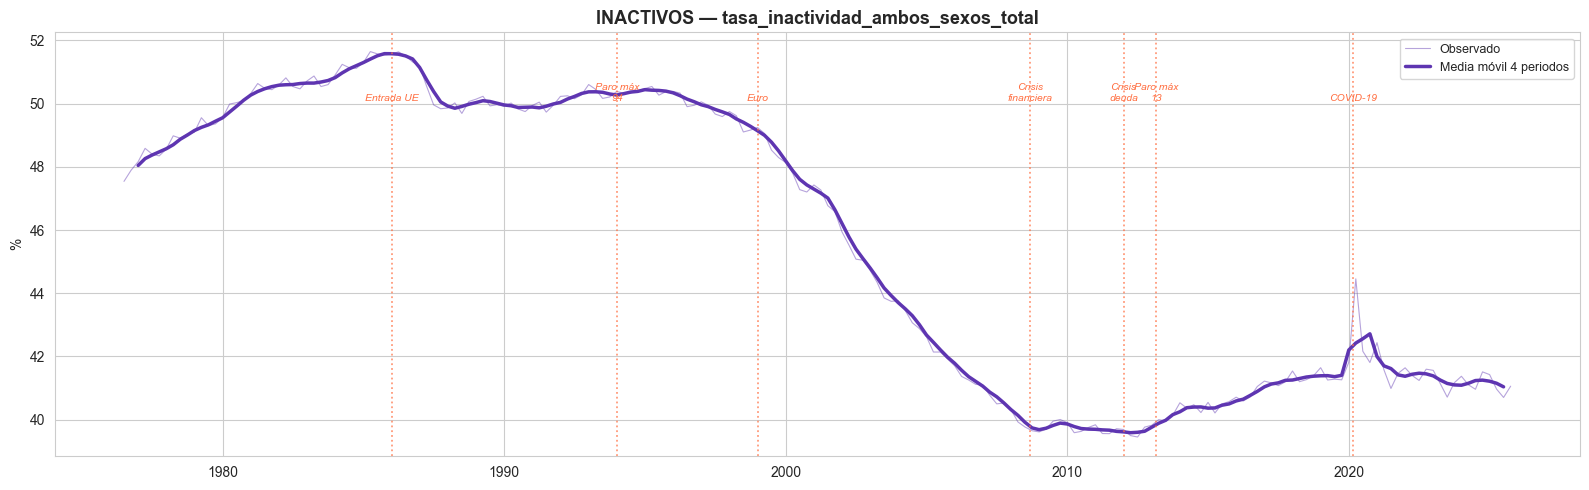

Mín: 39.45  (2012-07-01)
Máx: 51.65  (1985-04-01)


In [7]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

La tasa de inactividad recorre dos regímenes separados por una transición prolongada, sin los ciclos de expansión y contracción que marcan a las series de empleo. Arranca cerca del 47,5% en 1976-Q3, asciende hasta su techo histórico del 51,65% en 1985-Q2 y se mantiene en una meseta próxima al 50% durante el resto de los años ochenta y los noventa. A partir de 2000 inicia un descenso sostenido que la lleva a su suelo histórico, 39,45% en 2012-Q3, con los cinco valores más bajos de la muestra concentrados entre 2010 y 2012. Desde 2013 repunta de forma moderada hasta el entorno del 41%, con una perturbación puntual en 2020-Q2, en la que la media móvil llega a rozar el 42,7%, que se reabsorbe en los trimestres siguientes.

Por construcción contable la serie es la imagen especular de la tasa de actividad analizada en el notebook de población, ya que ambas suman la totalidad de la población de dieciséis y más años: el techo de inactividad de 1985 coincide con el suelo de actividad, y el suelo de inactividad de 2010-2012 con el máximo de participación. La trayectoria descendente del tramo central no responde al ciclo económico sino a un cambio de régimen demográfico y de participación, lo que anticipa una serie dominada por la tendencia y sin reversión a una media estable.

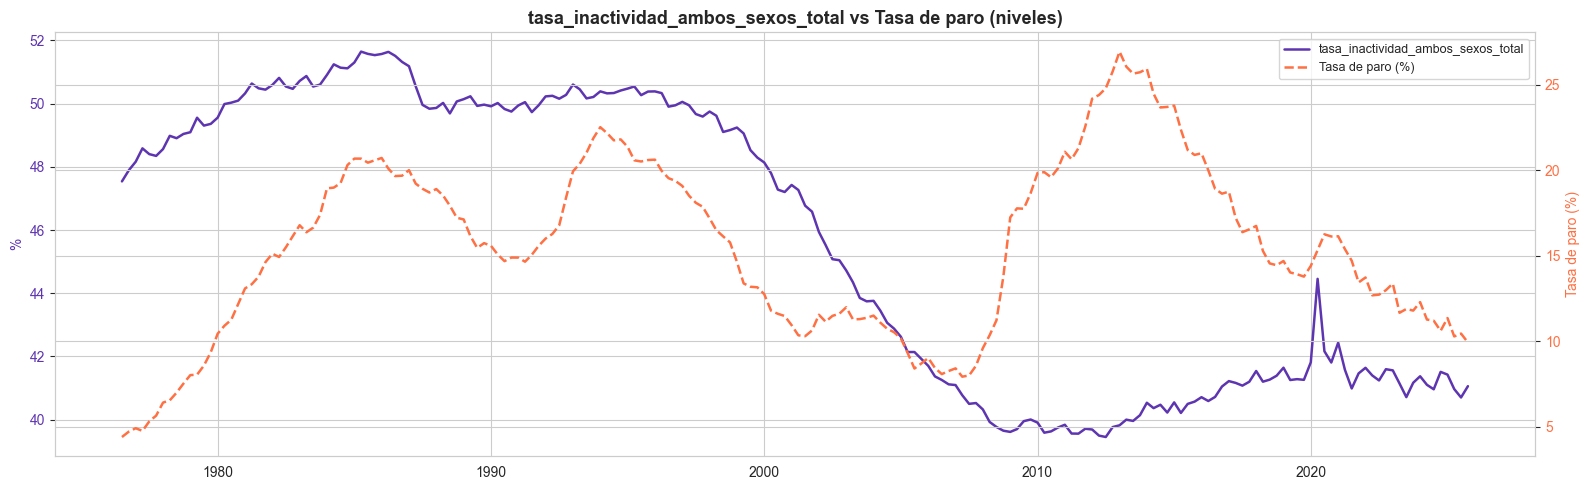

In [8]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación contemporánea en nivel entre la tasa de inactividad y la tasa de paro cambia de signo según el tramo, sin vínculo estable a lo largo de la muestra, en imagen especular del cruce de la tasa de actividad. Entre 1976 y 1985 ambas avanzan en el mismo sentido: la inactividad sube de aproximadamente 47,5% a 51,65% mientras el paro escala de cerca del 5% a aproximadamente el 21%. De 1985 a 1994 la inactividad se mantiene en su meseta próxima al 50% mientras el paro describe su propio ciclo, baja al entorno del 15% en 1991 y vuelve a acercarse al 24% en 1994, sin co-movimiento definido. Entre 1995 y 2007 las dos series descienden a la vez, la inactividad de aproximadamente 50,5% al entorno del 40% y el paro de cerca del 22% a aproximadamente el 8%.

El tramo 2007-2013 invierte la relación con nitidez: la inactividad toca su suelo histórico cercano al 39,5% justo cuando el paro alcanza su máximo próximo al 27%, coherente con una entrada de población a la actividad en plena destrucción de empleo. Desde 2014 el signo se mantiene inverso, con la inactividad repuntando hacia el 41-42% mientras el paro retrocede de aproximadamente el 27% al entorno del 10%, salvo la interrupción puntual de 2020. El co-movimiento en nivel queda dominado por la tendencia y la transición de régimen compartidas, de modo que el análisis cuantitativo de la relación se traslada a la sección 9 sobre la forma estacionaria. Las cifras del paro se leen contra la cuadrícula del eje derecho y son aproximadas.

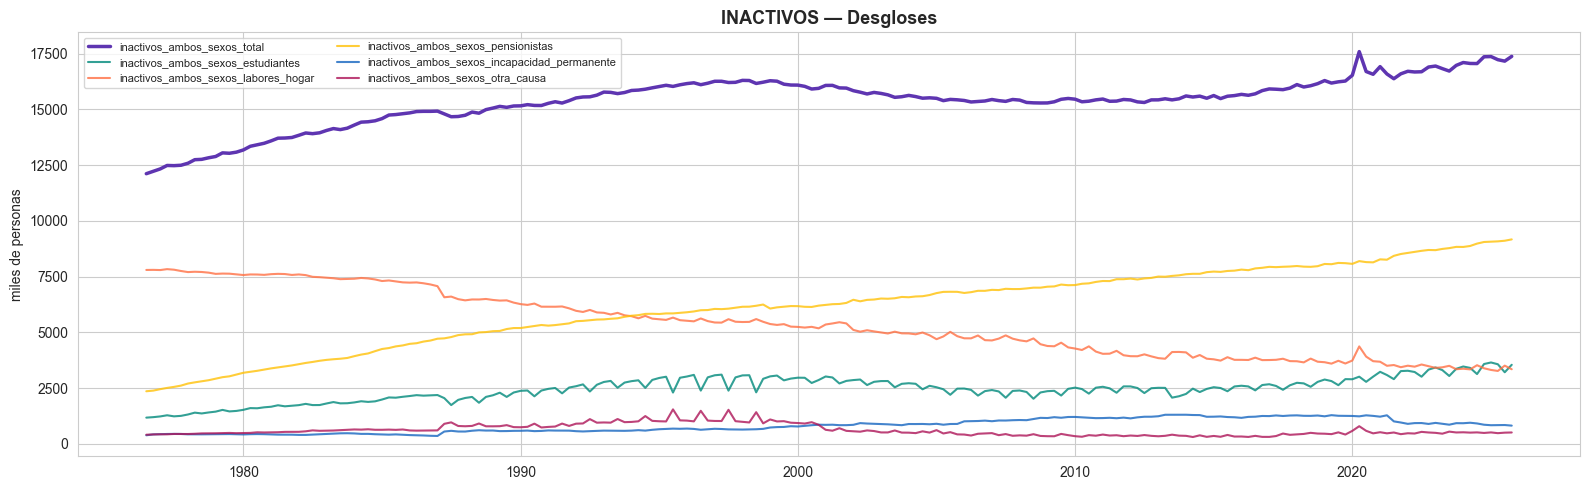

In [9]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    VAR_ABSOLUTA = DATASET_CONFIG['variable_principal_absoluta']
    ax.plot(df[VAR_ABSOLUTA].dropna().index, df[VAR_ABSOLUTA].dropna(), color=COLOR_PRINCIPAL, lw=2.5, label=VAR_ABSOLUTA, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(DATASET_CONFIG['unidades_absoluta'], fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El crecimiento del total de inactivos, de aproximadamente 12.100 miles en 1976 a aproximadamente 17.500 miles en 2025, lo explica un único componente en expansión: los pensionistas. El `inactivos_ambos_sexos_pensionistas` crece de forma casi monótona desde aproximadamente 2.350 miles en 1976 hasta aproximadamente 9.200 miles en 2025, supera a las labores del hogar en torno a 1990 y se consolida como la causa dominante. La trayectoria acompaña al envejecimiento demográfico y a la maduración del sistema de pensiones, con las cohortes de mayor tamaño alcanzando de forma progresiva la edad de jubilación.

El `inactivos_ambos_sexos_labores_hogar` describe el movimiento inverso: parte del nivel más alto de todos los componentes, aproximadamente 7.800 miles en 1976, y desciende de forma sostenida hasta aproximadamente 3.300 miles. La caída de unos 4.500 miles es la expresión cuantitativa de la incorporación de la mujer al mercado de trabajo. Los `inactivos_ambos_sexos_estudiantes` parten de aproximadamente 1.170 miles, mantienen una deriva ascendente suave hasta el entorno de 3.300 miles y convergen al final del periodo con las labores del hogar, con un diente de sierra estacional marcado por el ciclo académico que reduce el nivel en el tercer trimestre.

El `inactivos_ambos_sexos_incapacidad_permanente` crece despacio desde aproximadamente 380 miles hasta aproximadamente 1.200 miles, en línea con el envejecimiento de la fuerza de trabajo. El `inactivos_ambos_sexos_otra_causa` se mueve en un rango bajo, entre aproximadamente 400 y 1.500 miles, con picos en torno a 1995-1998 que coinciden con las caídas estacionales de los estudiantes y un máximo aislado en 2020-Q2 asociado al confinamiento. La alternancia entre estudiantes y `otra_causa` en los mismos trimestres es compatible con un efecto de clasificación del cuestionario EPA, hipótesis que el dato agregado no permite confirmar.

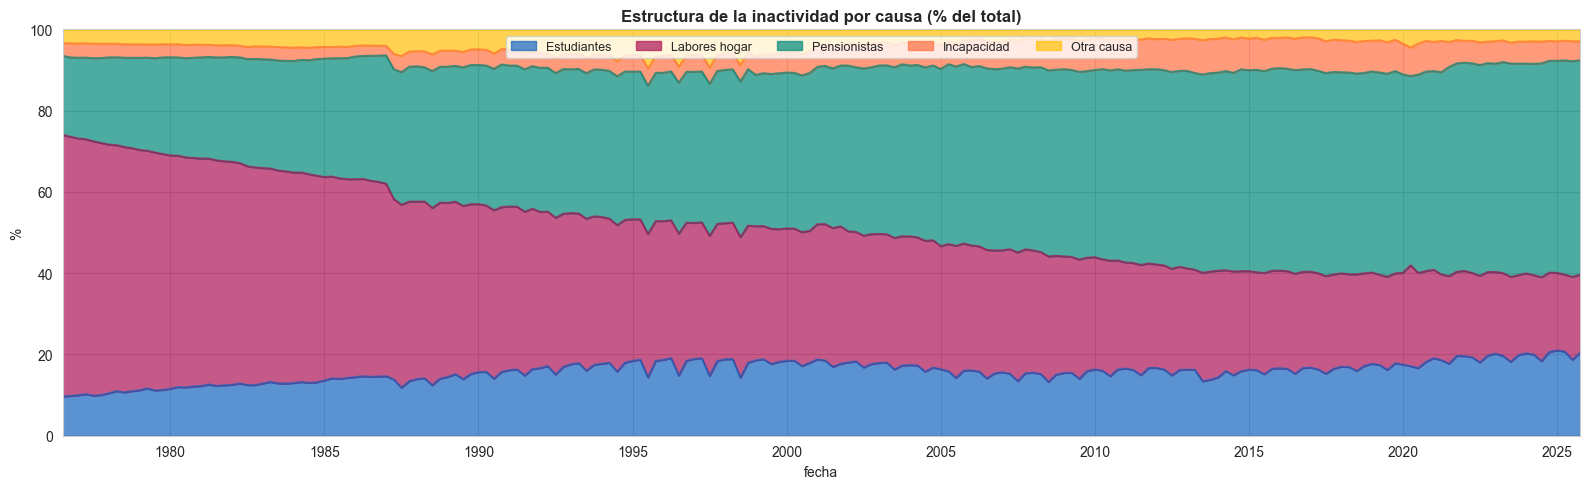

In [10]:
# Composición de la inactividad por causa (% del total)
cols_razones = {
    'Estudiantes': 'inactivos_ambos_sexos_estudiantes',
    'Labores hogar': 'inactivos_ambos_sexos_labores_hogar',
    'Pensionistas': 'inactivos_ambos_sexos_pensionistas',
    'Incapacidad': 'inactivos_ambos_sexos_incapacidad_permanente',
    'Otra causa': 'inactivos_ambos_sexos_otra_causa',
}
cols_disp = {k: v for k, v in cols_razones.items() if v in df.columns}

if cols_disp:
    df_shares = df[list(cols_disp.values())].div(df['inactivos_ambos_sexos_total'], axis=0) * 100
    df_shares.columns = list(cols_disp.keys())

    fig, ax = plt.subplots(figsize=(16, 5))
    df_shares.plot.area(ax=ax, color=['#1565C0', '#AD1457', '#00897B', '#FF7043', '#FFC107'], alpha=0.7)
    ax.set_title('Estructura de la inactividad por causa (% del total)', fontsize=12, fontweight='bold')
    ax.set_ylabel('%', fontsize=10)
    ax.legend(fontsize=9, ncol=5, loc='upper center')
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

### Análisis:

La composición de la inactividad se invierte por completo entre sus dos causas principales a lo largo de la muestra. En 1976 las labores del hogar concentran aproximadamente el 64% del total y los pensionistas en torno al 20%; en 2025 los pensionistas alcanzan aproximadamente el 53% y las labores del hogar caen hasta cerca del 20%. El cruce entre ambas se produce hacia 2000 y separa un régimen de inactividad dominado por la exclusión femenina del mercado laboral de otro dominado por el envejecimiento.

Los estudiantes mantienen un peso entre aproximadamente el 10% y el 20%, con la estacionalidad del ciclo académico visible en la banda superior del gráfico. La incapacidad permanente y la otra causa ocupan una franja reducida y estable, sin cambios estructurales más allá del pico de `otra_causa` en 2020-Q2 por el confinamiento.

El cambio de composición altera la naturaleza económica de la variable: los inactivos de los años setenta eran mayoritariamente mujeres en edad de trabajar con margen de incorporación al mercado, mientras que los actuales son en su mayoría jubilados sin retorno a la actividad. Esa diferencia es la que hace que el signo de la relación entre inactividad y paro dependa del tramo, tal como muestra el cruce en nivel de la sección anterior.

---
## 3. Distribución y Outliers

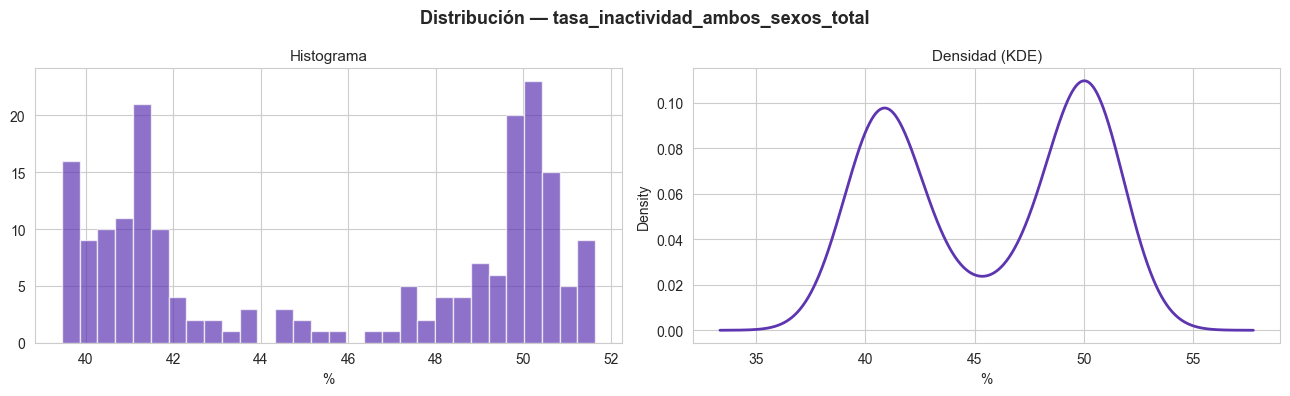

Asimetría (skewness): -0.101
Curtosis:             -1.788


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución de la tasa de inactividad es bimodal, con una moda baja en torno al 41% y otra alta cerca del 50% separadas por un valle alrededor del 45-46%, y presenta asimetría prácticamente nula (asimetría -0,101) con curtosis negativa (-1,788) propia de una densidad aplanada. Las dos modas no son una propiedad intrínseca de la serie sino el reflejo de los dos regímenes que recorre en nivel: la meseta de inactividad elevada anterior a 2000, próxima al 50%, y la meseta baja posterior a 2008, en el entorno del 41%, mientras que los valores intermedios corresponden a la transición y quedan poco poblados.

El perfil reproduce, desplazado, el de la tasa de actividad del notebook de población, cuyas modas se situaban en aproximadamente el 50% y el 59% con idéntica curtosis, coherente con que ambas tasas sean complementarias. La bimodalidad confirma la lectura de cambio de régimen y no de oscilación cíclica en torno a una media.

In [12]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha  valor
2012-07-01 39.452
2012-04-01 39.497
2011-07-01 39.558
2011-04-01 39.562
2010-04-01 39.589
1985-10-01 51.535
1986-01-01 51.571
1985-07-01 51.574
1986-04-01 51.638
1985-04-01 51.646


### Análisis:

La serie no contiene valores atípicos: ni el criterio IQR ni el z-score con umbral tres identifican observaciones fuera de rango. Los cinco valores más bajos, comprendidos entre 39,452% (2012-Q3) y 39,589% (2010-Q2), y los cinco más altos, entre 51,535% (1985-Q4) y 51,646% (1985-Q2), no son anomalías sino los extremos temporales de la trayectoria: el suelo de inactividad de la salida de la crisis y el techo de la reconversión industrial de mediados de los ochenta. El choque del confinamiento de 2020-Q2 eleva la tasa de forma transitoria por encima del 44% en el dato observado, pero permanece dentro del rango histórico y se reabsorbe de inmediato, por lo que no aparece como atípico del nivel y sí, en cambio, en la primera diferencia.

In [13]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

Los cuatro trimestres presentan distribuciones casi idénticas en mediana y recorrido, con cajas que se solapan en práctica totalidad sobre el rango histórico de la tasa. La separación entre trimestres es mínima y anticipa una estacionalidad despreciable, en línea con los índices estacionales de la sección siguiente. La amplitud de cada caja no recoge un efecto estacional sino el recorrido de la serie entre sus dos regímenes, ya que cada trimestre acumula observaciones de todo el periodo muestral.

---
## 4. Estacionalidad

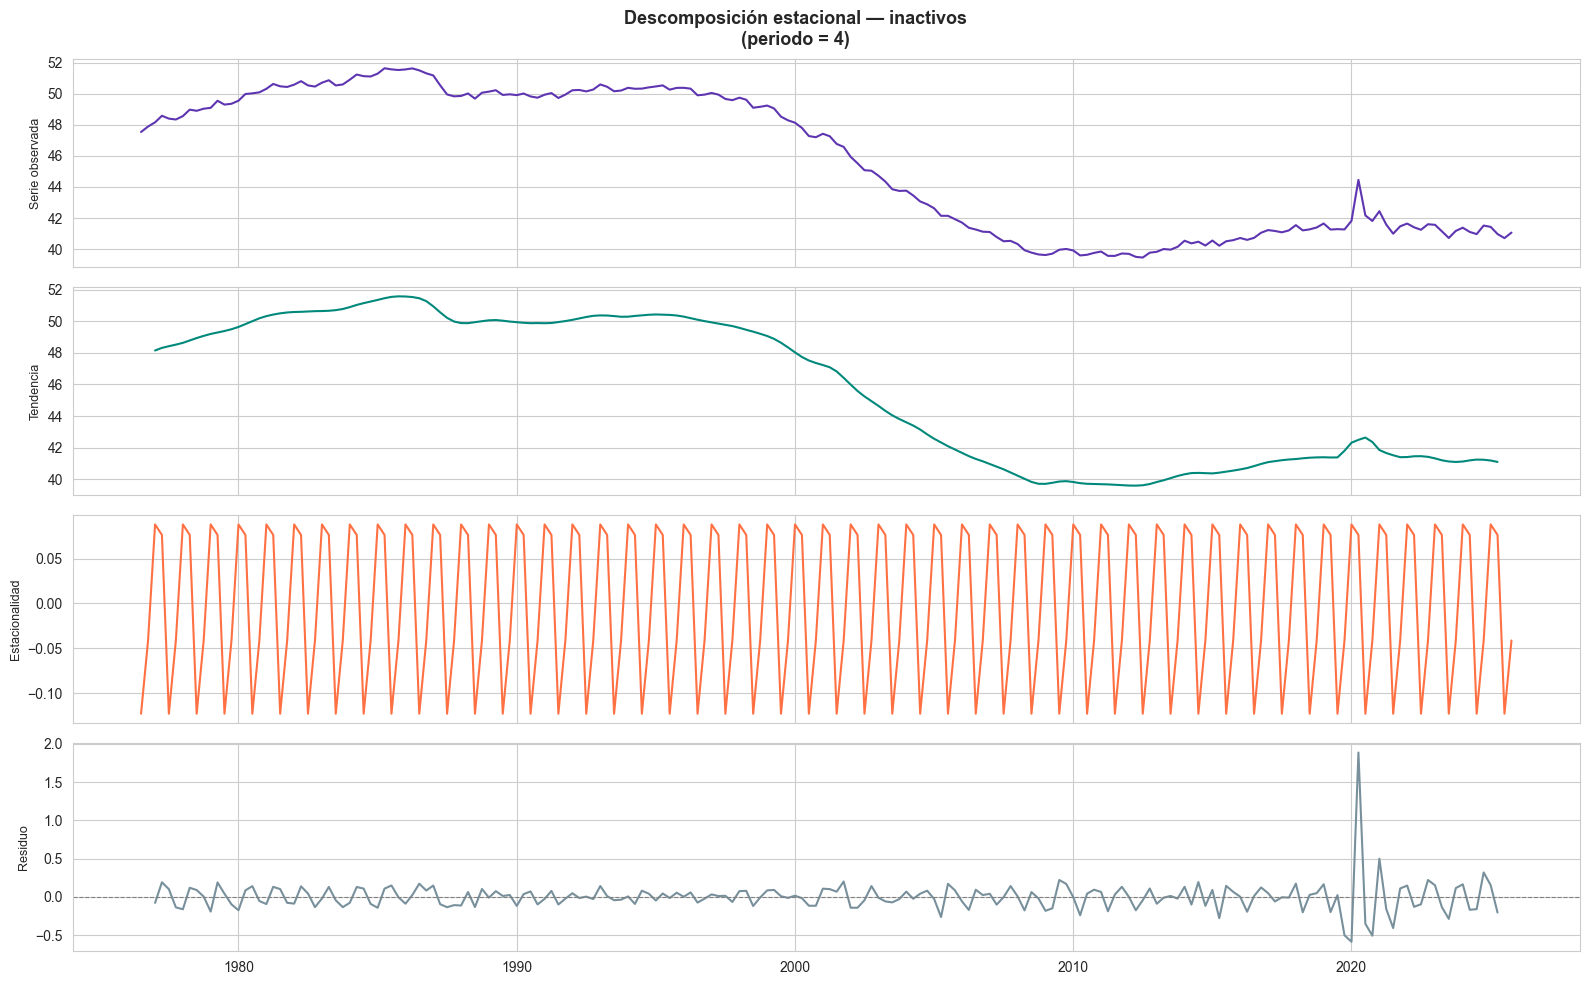

In [14]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición confirma una serie gobernada por la tendencia, con estacionalidad y residuo de magnitud menor. El componente de tendencia reproduce el perfil del nivel: asciende desde aproximadamente el 48% en 1976 hasta el entorno del 51,5% a mediados de los ochenta, se mantiene en una meseta próxima al 50% hasta finales de los noventa, cae de forma pronunciada entre 2000 y 2012 hasta aproximadamente el 39,5% y repunta después hacia el 41-42%, con un máximo local cercano al 42,7% alrededor de 2020-2021.

El componente estacional es constante y de amplitud reducida, del orden de 0,10 puntos porcentuales entre el trimestre alto y el bajo, despreciable frente al recorrido de doce puntos del nivel. El residuo se mantiene próximo a cero durante casi toda la muestra y solo se desvía de forma apreciable en 2020-Q2, con un pico cercano a 1,9 puntos seguido de varios trimestres de mayor varianza, que aísla el choque del confinamiento como perturbación transitoria y no como cambio de nivel.

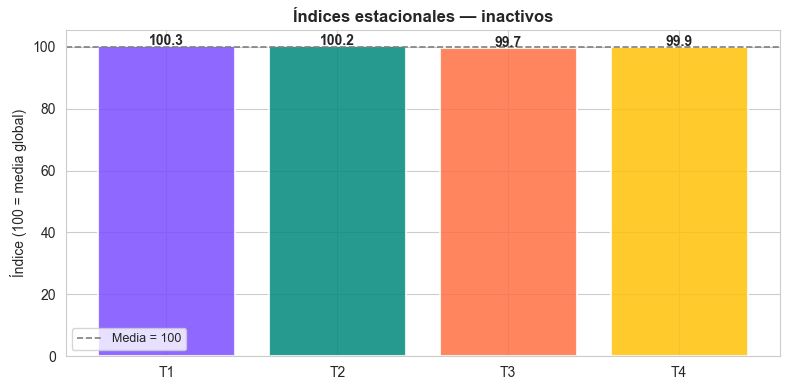

Índices estacionales:
T1   100.300
T2   100.200
T3    99.700
T4    99.900

Periodo con mayor inactivos: T1 (100.3)
Periodo con menor inactivos: T3 (99.7)


In [15]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales son planos: T1 marca el nivel más alto (100,3) y T3 el más bajo (99,7), con T2 (100,2) y T4 (99,9) intermedios, de modo que la oscilación máxima entre trimestres es de 0,6 sobre base 100. Sobre la media de la serie, 45,68%, esa diferencia equivale a aproximadamente 0,27 puntos porcentuales de tasa, magnitud sin relevancia económica. El patrón es coherente con el de la tasa de actividad, donde el trimestre alto y el bajo se invierten por tratarse de series complementarias, y confirma que la estacionalidad no condiciona la caracterización de la serie.

---
## 5. Cambios Periodo a Periodo

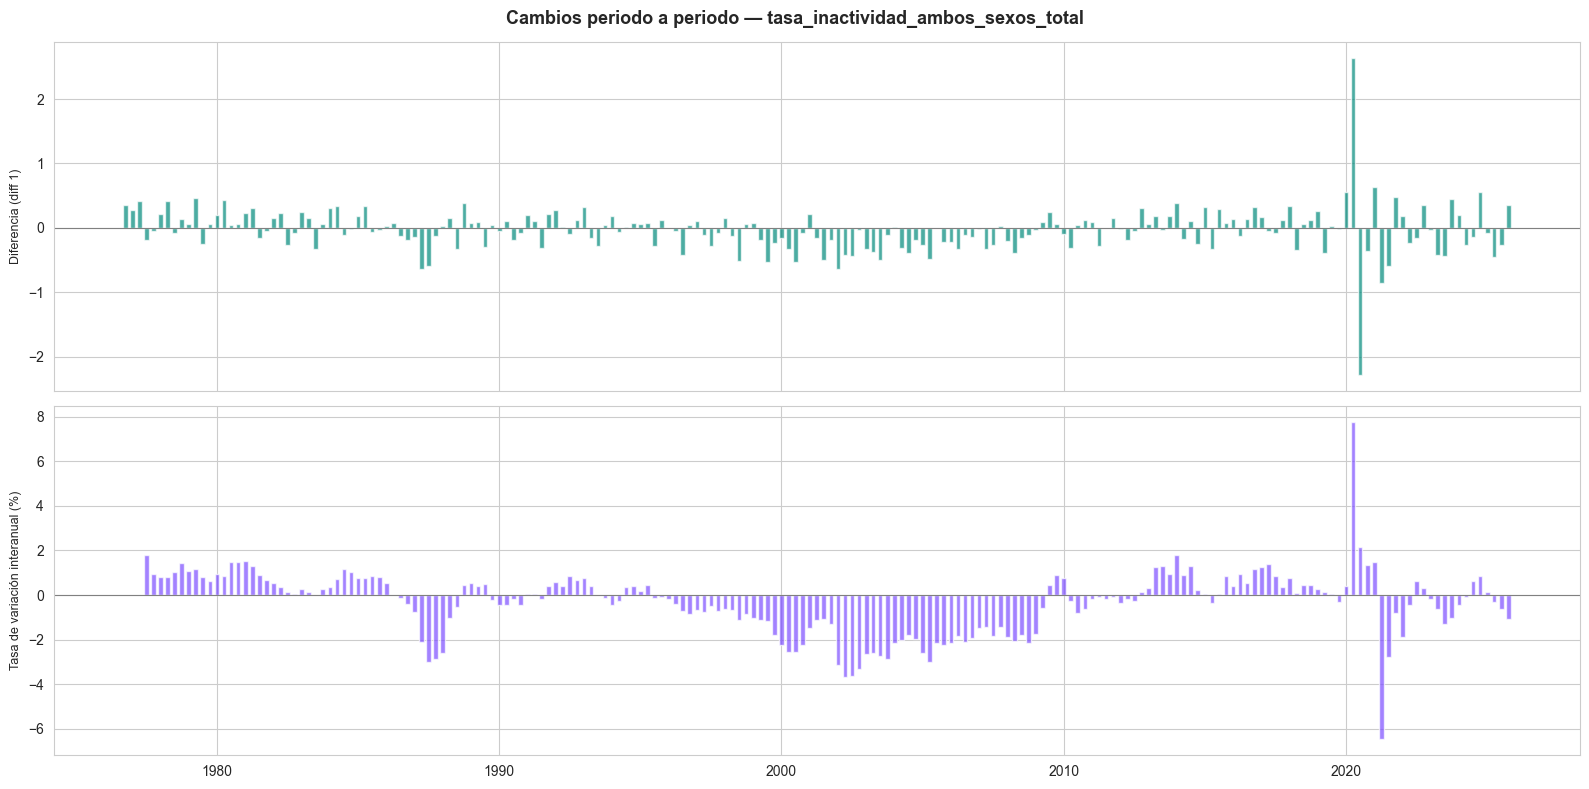

Estadísticas de la variación interanual (%):
count   194.000
mean     -0.310
std       1.450
min      -6.470
25%      -1.090
50%      -0.100
75%       0.620
max       7.760


In [16]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La primera diferencia oscila en torno a cero con amplitud reducida y homogénea durante toda la muestra, sin la asimetría brusca de las series de empleo, salvo el episodio de 2020: el confinamiento genera un salto cercano a +2,65 puntos en 2020-Q2 y un rebote próximo a -2,3 en el trimestre siguiente, muy por encima del recorrido habitual del resto de la serie. Esta concentración de la varianza en un único trimestre contamina la primera diferencia en ese punto, reproduce el comportamiento de la serie absoluta de inactivos y queda documentada como particularidad para la fase de transformación.

La variación interanual presenta una media de -0,31% con desviación típica de 1,45 y recorrido entre -6,47% y +7,76%, ambos extremos en el entorno de 2020. A diferencia de la primera diferencia, conserva una estructura de signo por tramos: negativa y persistente entre 2000 y 2008, durante la fase de descenso del nivel, y positiva en el arranque de la muestra y en la recuperación de 2010-2015, lo que traslada a la tasa de cambio la tendencia presente en el nivel.

---
## 6. Estacionariedad y Autocorrelación

In [17]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                      serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
 tasa_inactividad_ambos_sexos_total (nivel)         ct    -1.070  0.727           False      0.239   0.010             True NO ESTACIONARIA
tasa_inactividad_ambos_sexos_total (diff 1)          c    -2.682  0.077           False      0.517   0.038             True NO ESTACIONARIA
tasa_inactividad_ambos_sexos_total (diff 4)          c    -1.974  0.298           False      0.358   0.095            False NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  tasa_inactividad_ambos_sexos_total (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-1.070, p=0.7269 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.239, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  tasa_inactividad_ambos_sexos_total (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-2.682, p=0.07

### Análisis:

En niveles la serie es no estacionaria sin ambigüedad. El ADF, cuya hipótesis nula es la existencia de raíz unitaria, no la rechaza (estadístico -1,070, p=0,7269), y el KPSS, cuya nula es la estacionariedad, sí la rechaza (estadístico 0,239, p=0,0100); ambos convergen en el resultado esperado dada la transición de régimen que domina la trayectoria.

La primera diferencia se acerca a la estacionariedad sin alcanzarla de forma limpia. El ADF rechaza la raíz unitaria al 10% pero no al 5% (estadístico -2,682, p=0,0772) y el KPSS mantiene el rechazo de la estacionariedad (estadístico 0,517, p=0,0379), de modo que la diferenciación regular elimina la persistencia del nivel pero deja una serie todavía no estacionaria según el criterio conjunto. La diferencia estacional de orden cuatro queda en zona ambigua, con el ADF que no rechaza (estadístico -1,974, p=0,2979) y el KPSS que tampoco lo hace (estadístico 0,358, p=0,0951); bajo criterio conservador se clasifica como no estacionaria.

Entre las transformaciones probadas la primera diferencia es la más próxima a la estacionariedad y la forma sobre la que se cruza con el paro en la sección 9; la variación interanual y la transformación logarítmica no se han testeado, esta última sin aplicación sobre una tasa acotada. El diagnóstico coincide trimestre a trimestre con el de la tasa de actividad del notebook de población, resultado esperable porque una y otra suman una constante y los tests ADF y KPSS son invariantes al cambio de signo y a la traslación. La elección final de la forma con que la serie entrará en cada modelo se resuelve en la fase de feature engineering.

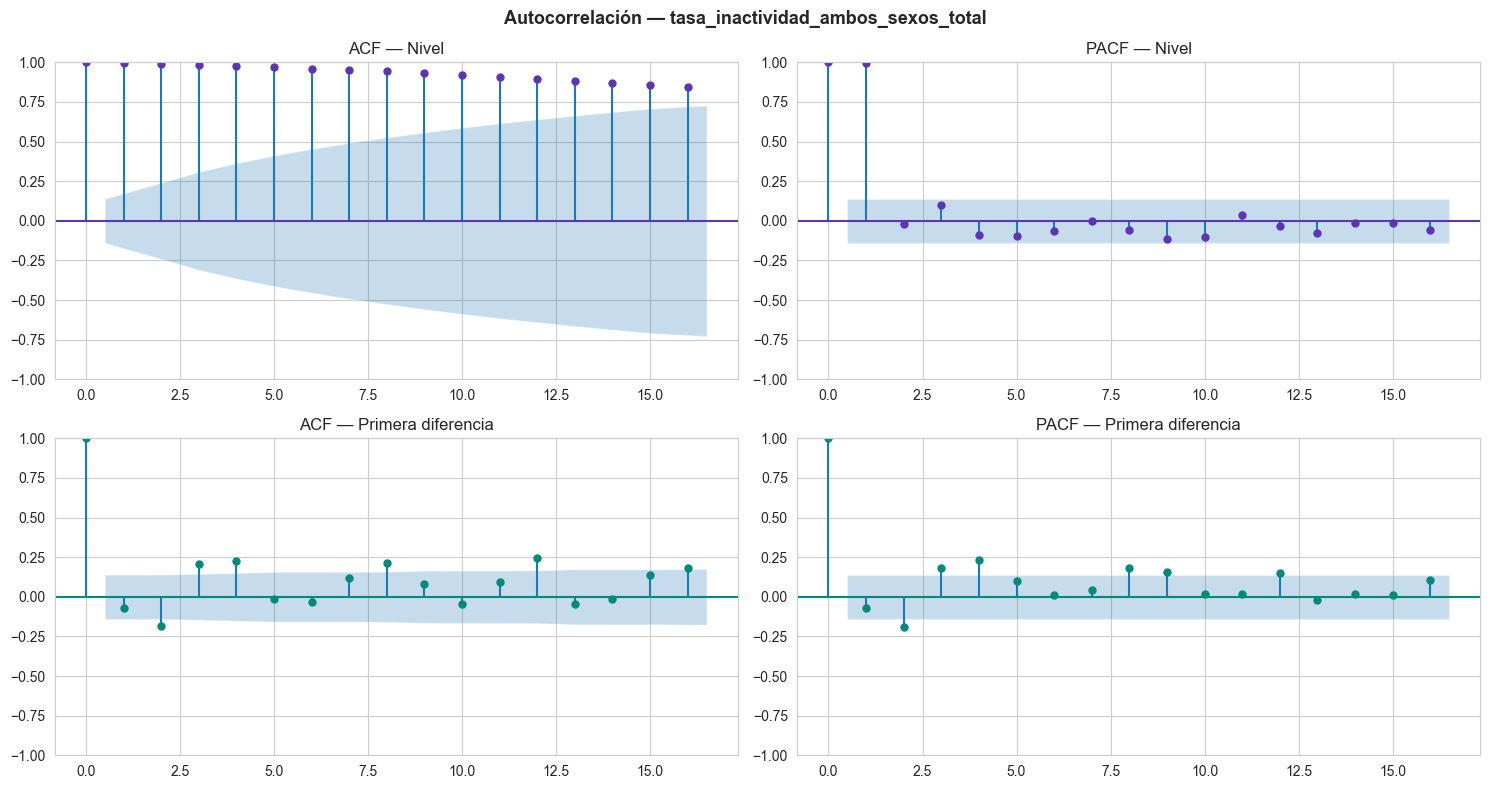

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles el ACF decae muy despacio, desde 0,99 en el primer retardo hasta aproximadamente 0,84 en el retardo dieciséis sin entrar en las bandas de confianza, la firma de persistencia propia de una serie con raíz unitaria. El PACF concentra toda la estructura en un único pico en el primer retardo, cercano a la unidad, con el resto de retardos dentro de las bandas, patrón de un proceso autorregresivo de primer orden con raíz próxima a uno.

La primera diferencia cambia el cuadro: el ACF cae dentro de las bandas desde los primeros retardos, lo que confirma que la diferenciación elimina la persistencia detectada en nivel y concuerda con el acercamiento del ADF al rechazo. Persisten, no obstante, picos leves en los retardos múltiplos de cuatro, cercanos a 0,23 en el retardo cuatro y a 0,24 en el doce, junto a un retardo dos ligeramente negativo, que señalan una estructura trimestral residual no absorbida por la diferencia regular. El corte en el PACF identifica la componente autorregresiva y el patrón del ACF la de medias móviles, sin que ninguno invierta su lectura; la estructura estacional residual coincide con la observada en la tasa de actividad.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [19]:
df_der = pd.DataFrame(index=df.index)

col_total = 'inactivos_ambos_sexos_total'
for razon, col in [
    ('labores_hogar', 'inactivos_ambos_sexos_labores_hogar'),
    ('pensionistas', 'inactivos_ambos_sexos_pensionistas'),
    ('estudiantes', 'inactivos_ambos_sexos_estudiantes'),
]:
    if col in df.columns:
        df_der[f'share_{razon}'] = df[col] / df[col_total] * 100

if all(c in df.columns for c in ['inactivos_mujeres_total', 'inactivos_hombres_total']):
    df_der['ratio_feminizacion_inactividad'] = (
        df['inactivos_mujeres_total'] / (df['inactivos_mujeres_total'] + df['inactivos_hombres_total']) * 100
    )

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (4):


,share_labores_hogar,share_pensionistas,share_estudiantes,ratio_feminizacion_inactividad
count,198.000,198.000,198.000,198.000
mean,35.591,39.454,15.758,65.092
std,12.221,9.408,2.542,6.019
min,18.962,19.449,9.685,56.964
25%,25.492,33.467,14.086,59.014
50%,32.622,38.909,16.062,64.738
75%,43.214,48.577,17.704,69.343
max,64.361,53.066,21.000,77.778


### Análisis:

Las cuatro variables derivadas capturan la transformación estructural de la composición de la inactividad documentada en las secciones anteriores, ahora expresada en términos relativos sobre el total de inactivos.

El `share_labores_hogar` presenta la mayor dispersión del conjunto, con una media de 35,6% y un rango de 18,96% a 64,36%, y una desviación típica de 12,2 puntos porcentuales. La distancia entre mínimo y máximo de más de 45 puntos cuantifica la magnitud de la transformación estructural: en los años 70 las labores del hogar representaban casi dos tercios de la inactividad total, mientras que en la actualidad no alcanzan el 20%. La mediana (32,6%) por debajo de la media (35,6%) indica asimetría positiva, coherente con que los valores altos del inicio de la serie elevan la media por encima del valor central.

El `share_pensionistas` describe la trayectoria opuesta, con una media de 39,5% y un rango de 19,4% a 53,1%. Su desviación típica de 9,4 puntos es inferior a la de labores del hogar, reflejando que el crecimiento del peso de los pensionistas ha sido más gradual y sostenido que la caída del peso de las labores del hogar. La mediana (38,9%) próxima a la media indica distribución más simétrica, coherente con una tendencia ascendente relativamente lineal.

El `share_estudiantes` es la variable más estable, con una media de 15,8% y una desviación típica de apenas 2,5 puntos, confirmando la ausencia de tendencia estructural en esta categoría documentada en los gráficos de nivel. El rango de 9,7% a 21,0% refleja principalmente la variabilidad estacional por ciclo académico.

El `ratio_feminizacion_inactividad` (proporción de mujeres sobre el total de inactivos) oscila entre 57,0% y 77,8%, con una media de 65,1% y una mediana de 64,7%. Que las mujeres representen sistemáticamente más del 55% de los inactivos a lo largo de todo el periodo, incluso tras la incorporación masiva al mercado laboral, refleja la combinación de mayor longevidad femenina, que eleva el peso de las pensionistas mujeres, y la persistencia residual de las labores del hogar como causa de inactividad mayoritariamente femenina.

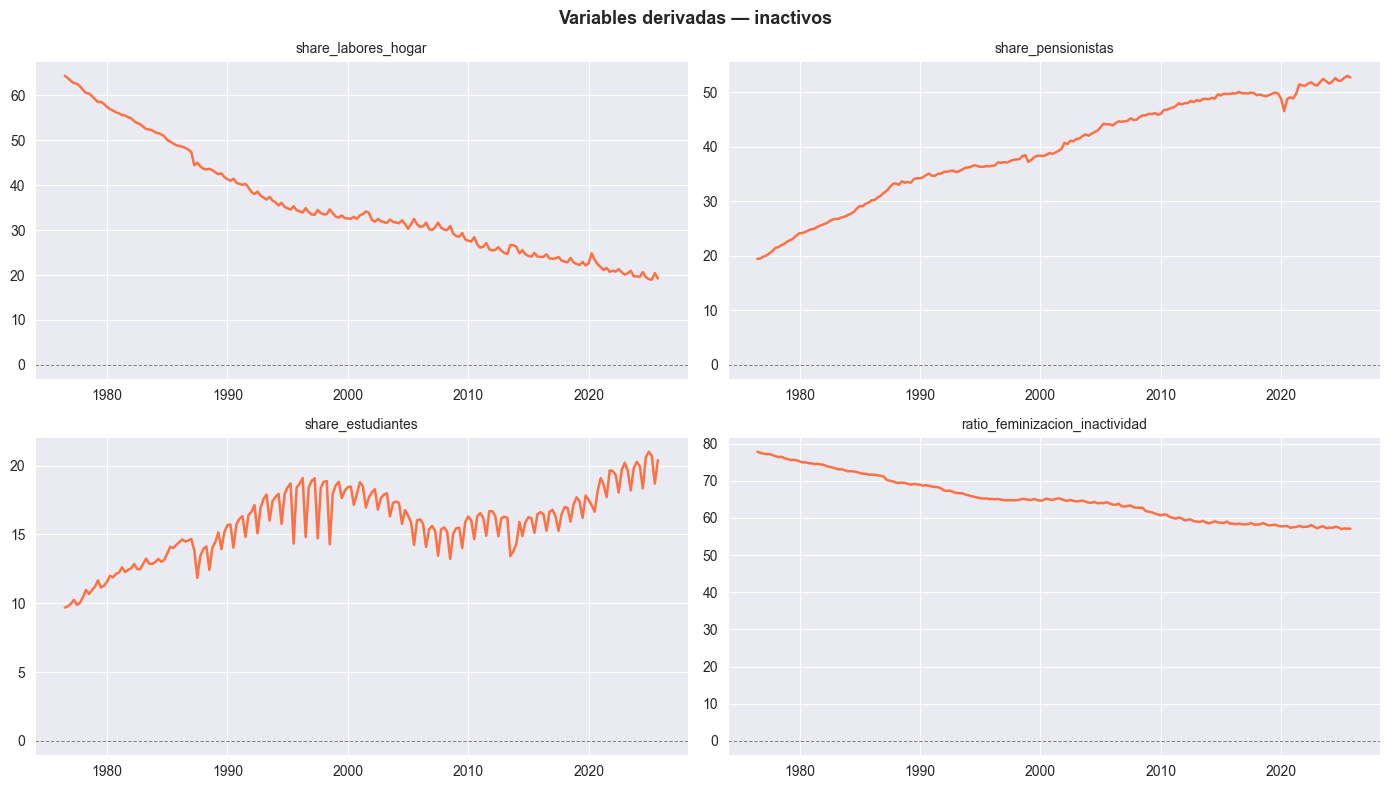

In [20]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

El `share_labores_hogar` confirma la caída estructural más pronunciada del conjunto: desciende de manera casi lineal desde aproximadamente 63% en 1977 hasta aproximadamente 20% en 2025, con una aceleración visible entre 1977 y 1990 y una desaceleración gradual posterior que sugiere que el proceso de incorporación femenina se aproxima a su límite estructural. No se observan interrupciones cíclicas relevantes, lo que confirma que esta transformación es demográfica e irreversible.

El `share_pensionistas` describe la trayectoria opuesta con tres fases diferenciadas: crecimiento rápido desde aproximadamente 20% en 1977 hasta aproximadamente 35% en 1990, aceleración entre 1990 y 2010 hasta aproximadamente 48%, y una meseta con ligera volatilidad desde 2010 hasta el máximo de aproximadamente 53% en 2025. La interrupción visible en torno a 2020 es el efecto del confinamiento: el pico de inactivos por `otra_causa` en 2020-Q2 diluyó temporalmente el peso relativo de los pensionistas antes de recuperarse.

El `share_estudiantes` muestra una tendencia ascendente suave desde aproximadamente 10% hasta aproximadamente 20%, pero con una característica diferenciadora respecto a las otras variables: la amplitud de la estacionalidad crece visiblemente a lo largo del tiempo, siendo notablemente mayor en los últimos veinte años que en los años 70-80. Este aumento de amplitud no refleja mayor estacionalidad real sino el efecto denominador: conforme el total de inactivos se estabiliza en un rango más estrecho, las oscilaciones absolutas de los estudiantes representan una fracción porcentual mayor del total.

El `ratio_feminizacion_inactividad` desciende de forma sostenida desde aproximadamente 78% en 1977 hasta aproximadamente 58% en la actualidad, con la caída más intensa entre 1977 y 2005 coincidiendo con la incorporación masiva de la mujer al mercado laboral. La estabilización posterior en torno al 58-60% refleja que el proceso de convergencia ha alcanzado un límite estructural: la mayor longevidad femenina y la persistencia residual de las labores del hogar como causa de inactividad mayoritariamente femenina impiden que esta ratio descienda por debajo de ese umbral.

In [21]:
# ── Guardar dataset enriquecido ───────────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]
    df.to_csv(ruta)
    print(f'CSV sobreescrito: {ruta.name}')
    print(f'  {len(df_der.columns)} variables añadidas: {list(df_der.columns)}')
    print(f'  Columnas totales: {len(df.columns)}')
else:
    print('No se crearon variables derivadas.')

CSV sobreescrito: inactivos_situacion_inactividad_sexo.csv
  4 variables añadidas: ['share_labores_hogar', 'share_pensionistas', 'share_estudiantes', 'ratio_feminizacion_inactividad']
  Columnas totales: 26


---
## 8. Tabla Resumen

In [22]:
est_nivel = resultados_est[resultados_est['serie'].str.contains('nivel')]['conclusion'].values[0]
est_diff1 = resultados_est[resultados_est['serie'].str.contains('diff 1')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
    'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
    'N obs':                 len(y.dropna()),
    'Media':                 y.mean().round(2),
    'Mediana':               y.median().round(2),
    'Std':                   y.std().round(2),
    'CV (%)':                (y.std() / y.mean() * 100).round(1),
    'Mín (fecha)':           f'{y.min():.1f} ({y.idxmin().date()})',
    'Máx (fecha)':           f'{y.max():.1f} ({y.idxmax().date()})',
    'Outliers IQR':          len(outliers_iqr),
    '% faltantes':           f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':  est_nivel,
    'Estacionaria (diff 1)': est_diff1,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN ')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN 
                                                    Valor
Dataset                                         inactivos
Variable               tasa_inactividad_ambos_sexos_total
Frecuencia                                     trimestral
Rango                             1976-07-01 — 2025-10-01
N obs                                                 198
Media                                              45.680
Mediana                                            47.240
Std                                                 4.480
CV (%)                                              9.800
Mín (fecha)                             39.5 (2012-07-01)
Máx (fecha)                             51.6 (1985-04-01)
Outliers IQR                                            0
% faltantes                                          0.0%
Estacionaria (nivel)                      NO ESTACIONARIA
Estacionaria (diff 1)                     NO ESTACIONARIA
Periodo más alto                                       T1

### Análisis:

La tasa de inactividad es la serie de menor recorrido relativo de las tres tasas de población: con media de 45,68%, mediana de 47,24% y desviación típica de 4,48 puntos, su coeficiente de variación es del 9,8%, del mismo orden que el de la tasa de actividad (8,2%) y la de empleo (10,2%). La mediana por encima de la media recoge la ligera asimetría negativa de la distribución bimodal, en la que la moda baja del 41% arrastra la media por debajo del valor central. La serie cubre 198 trimestres entre 1976-Q3 y 2025-Q4 sin valores faltantes ni atípicos, con suelo de 39,5% en 2012-Q3 y techo de 51,6% en 1985-Q2.

En cuanto a la forma, la serie es no estacionaria en nivel y sigue siéndolo en primera diferencia, que es sin embargo la transformación más próxima a la estacionariedad y la adoptada para el cruce con el paro. Ninguna de las transformaciones probadas estacionariza la serie de forma limpia, salvedad que queda documentada; la elección definitiva de la forma con que entrará en cada modelo se difiere a la fase de feature engineering.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Inactivos** y el desempleo (EPA, desde 1976Q3).

In [23]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                       # primera diferencia
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                               #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 tasa_inactividad_ambos_sexos_total
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 197


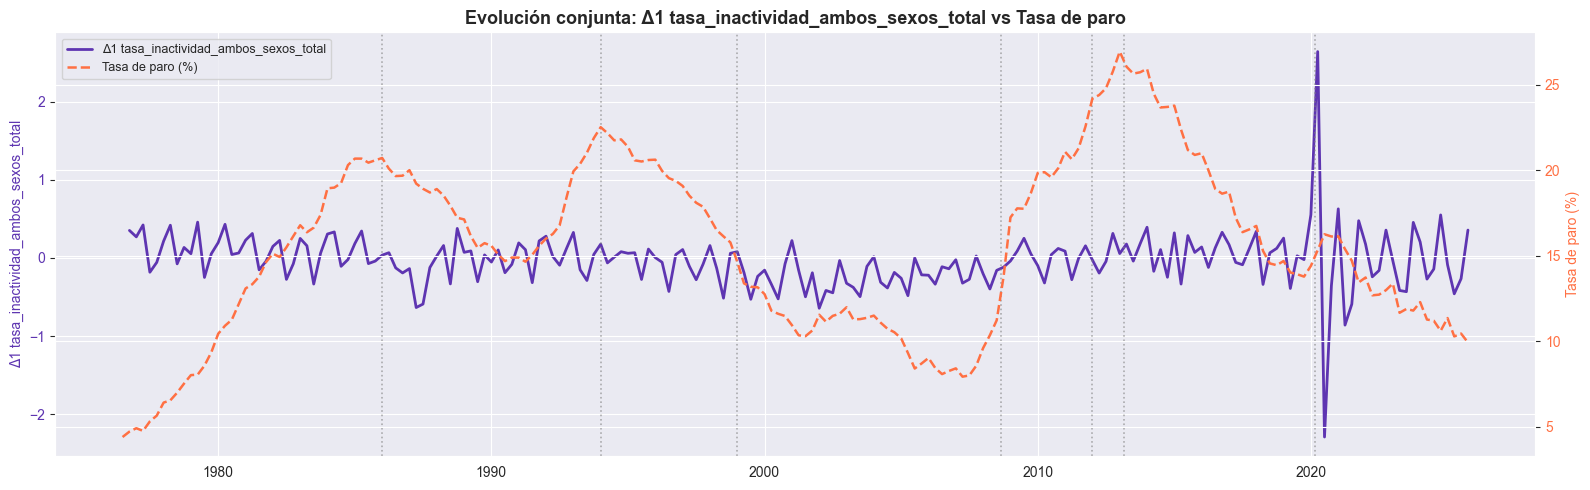

In [24]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

En su forma estacionaria, la primera diferencia de la tasa de inactividad pierde el co-movimiento que mostraba en nivel con la tasa de paro. La serie diferenciada oscila en torno a cero con amplitud reducida y homogénea durante toda la muestra, mientras el paro describe sus tres grandes olas, con máximos próximos al 21% en 1985, al 24% en 1994 y al 27% en 2013, sin que la amplitud ni el signo de la diferencia acompañen a esas olas. El único episodio que rompe la escala es 2020-Q2, con el salto cercano a +2,65 puntos y el rebote próximo a -2,3 del confinamiento. La lectura visual anticipa una relación contemporánea débil, que el análisis de correlación cuantifica a continuación.

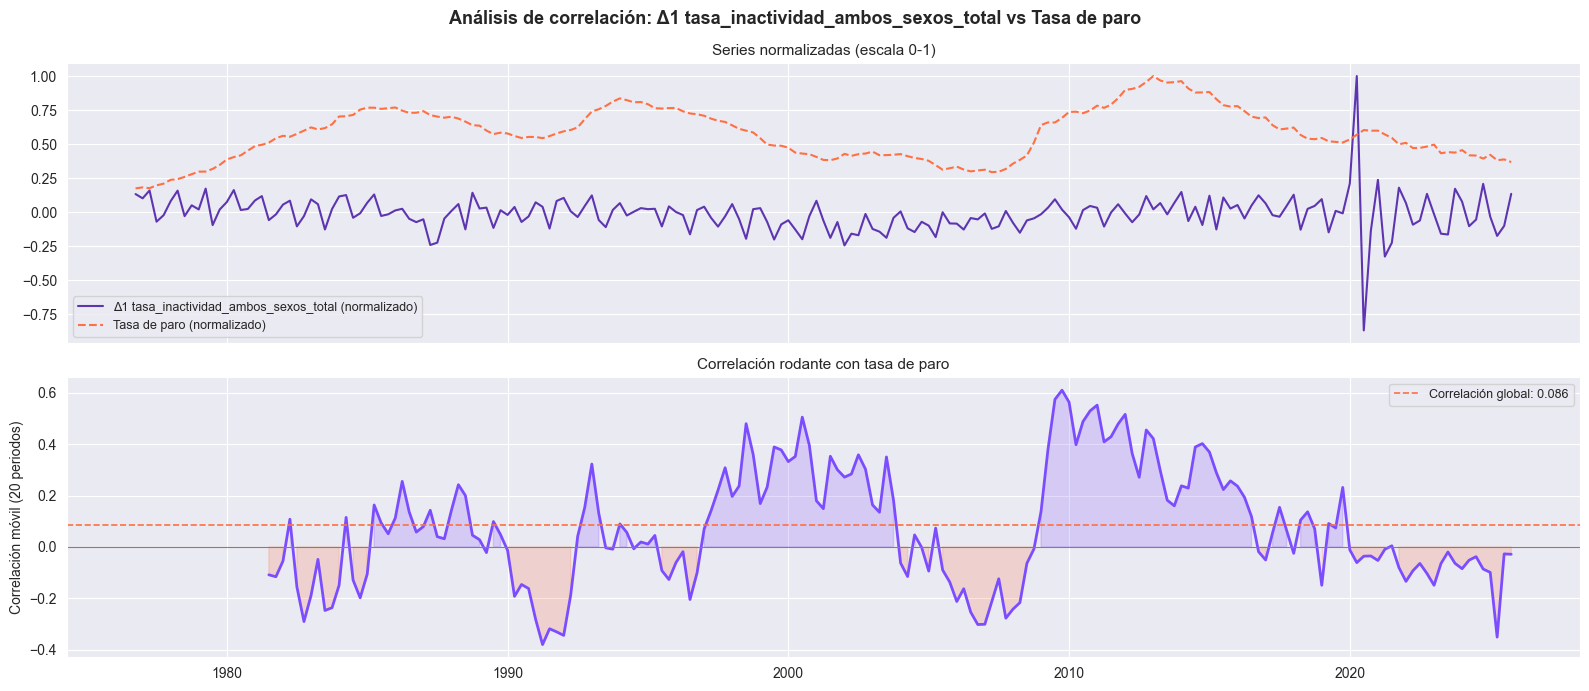

Correlación de Pearson global: 0.0857


In [25]:
ventana_corr = 20

df_cross = pd.DataFrame({'tasa_inactividad': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['tasa_inactividad'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['tasa_inactividad'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['tasa_inactividad'] / df_cross['tasa_inactividad'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la primera diferencia de la tasa de inactividad y la tasa de paro es de 0,0857, prácticamente nula, pero la correlación rodante revela que esa cifra agregada esconde una relación intensa y de signo cambiante por regímenes. Con ventana de veinte trimestres, la rodante recorre un rango aproximado de -0,4 a +0,6 y cruza el cero en varias ocasiones: es negativa en los primeros años ochenta, positiva a mediados de esa década, vuelve a terreno negativo hacia 1991 con un mínimo cercano a -0,35, se torna positiva entre 1997 y 2003 con un máximo próximo a +0,5, cae de nuevo hasta cerca de -0,35 en la antesala de la crisis de 2008 y alcanza su valor más alto, cercano a +0,6, entre 2009 y 2012. En el tramo final vuelve a girar a negativo, con un mínimo próximo a -0,35 en 2024-2025.

Que la correlación global se acerque a cero no descarta la variable: la rodante es fuerte y mantiene el signo durante periodos prolongados, lo que apunta a un poder predictivo condicionado al régimen más que a una relación contemporánea estable. El patrón es el reflejo, con signo invertido, del obtenido para la tasa de actividad, cuya correlación global era de -0,0857 y cuya rodante recorría el rango opuesto, coherente con que la primera diferencia de una y otra tasa difieran solo en el signo.

In [26]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='tasa_inactividad', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Tasa de paro',
    labels={
        'tasa_inactividad': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

La dispersión por década confirma que el nivel del paro lo fija el régimen y no la variación de la inactividad. Las nubes de cada década se separan en vertical, con los 2000 en la franja baja de paro, entre aproximadamente el 8% y el 12%, y los 2010 en la alta, por encima del 15% y hasta el 26%, mientras que en horizontal todas se concentran en torno a una primera diferencia próxima a cero, dentro de la banda aproximada de -0,5 a +0,5. La recta de tendencia global tiene pendiente ligeramente positiva pero muy plana, coherente con la correlación de 0,0857: dentro de cada década apenas hay relación entre la diferencia de la inactividad y el nivel del paro. Los dos puntos extremos en horizontal corresponden al confinamiento de 2020, con la diferencia cercana a -2,3 y a +2,65.

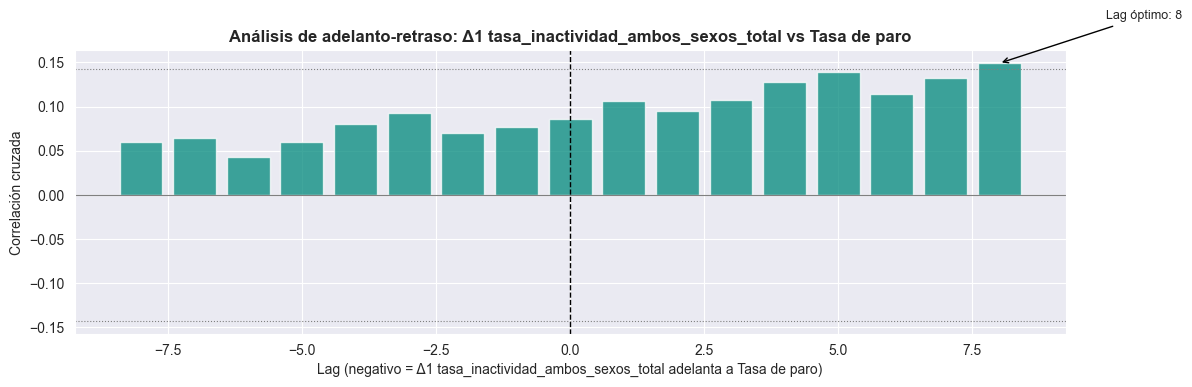

Lag con máxima correlación: 8 periodos
Correlación en ese lag: 0.1490
Banda de significancia (±2/√N): ±0.1425


In [27]:
max_lag = LAGS_ACF // 2

sa = (df_cross['tasa_inactividad'] - df_cross['tasa_inactividad'].mean()) / df_cross['tasa_inactividad'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a Tasa de paro)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Tasa de paro', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso sitúa la correlación máxima en el retardo +8, con un valor de 0,1490 que apenas supera la banda de significancia de ±0,1425, lo que indica que la tasa de paro antecede en ocho trimestres a la primera diferencia de la inactividad. La correlación cruzada es positiva en todos los retardos y forma una meseta creciente hacia los positivos altos, sin un pico aislado. En los retardos operativos de corto plazo, del contemporáneo al cuarto, los valores se mantienen entre aproximadamente 0,085 y 0,130, todos dentro de la banda y por tanto no distinguibles de cero. El retardo óptimo es, en consecuencia, descriptivo de una relación de medio plazo y no una señal aprovechable en el horizonte de predicción. El resultado replica con signo positivo el de la tasa de actividad, donde el mismo retardo +8 arrojaba una correlación de -0,149 con idéntica banda.